# Yearly Request Data Analysis

This notebook performs a complete analysis of the `yearly_request.csv` dataset, covering:
1. Data import
2. Histogram export
3. Adding a derived column and exporting the modified dataset
4. Column extraction
5. Customer grouping by request amount
6. Data summary
7. Total request value calculation

## Setup — Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


---
## Task 1 — Import Data

Load `yearly_request.csv` into a pandas DataFrame called `requests`.

In [2]:
requests = pd.read_csv('yearly_request.csv')

print("Shape:", requests.shape)
print("\nColumn dtypes:")
print(requests.dtypes)
print("\nFirst 5 rows:")
requests.head()

Shape: (10000, 4)

Column dtypes:
cust_id             int64
req_total         float64
no_of_requests      int64
gender                str
dtype: object

First 5 rows:


,cust_id,req_total,no_of_requests,gender
0,100001,800.64,3,F
1,100002,217.53,3,F
2,100003,74.58,2,M
3,100004,498.60,3,M
4,100005,723.11,4,F


---
## Task 2 — Export Histogram of Number of Requests

Plot and save a histogram of the `no_of_requests` column to `requests_histogram.jpg`.

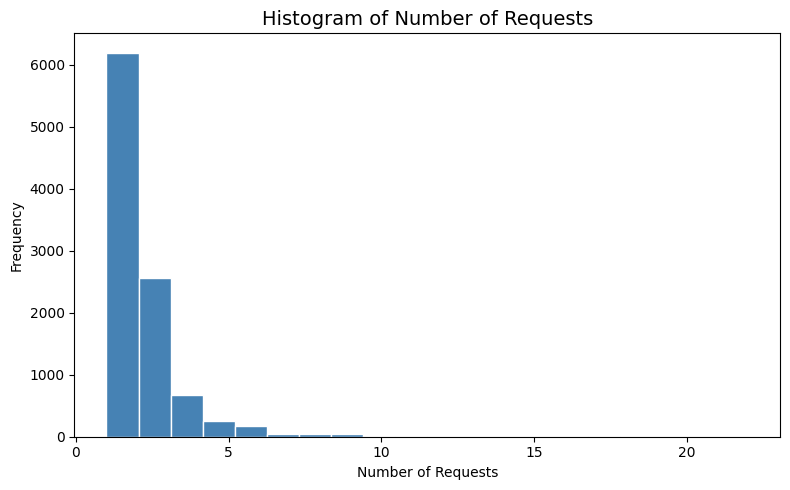

Histogram saved to requests_histogram.jpg


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
requests['no_of_requests'].plot.hist(bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Histogram of Number of Requests', fontsize=14)
ax.set_xlabel('Number of Requests')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('requests_histogram.jpg', format='jpeg', dpi=150)
plt.show()
print("Histogram saved to requests_histogram.jpg")

---
## Task 3 — Add `per_request` Column & Export Modified Dataset

Compute `per_request = req_total / no_of_requests` (average value per request) and export the updated DataFrame to `requests_modified.txt` as a tab-separated file.

In [4]:
requests['per_request'] = requests['req_total'] / requests['no_of_requests']

requests.to_csv('requests_modified.txt', sep='\t', index=False)

print("'per_request' column added. Modified dataset exported to requests_modified.txt")
print("\nSample of new column:")
requests[['cust_id', 'req_total', 'no_of_requests', 'per_request']].head(10)

'per_request' column added. Modified dataset exported to requests_modified.txt

Sample of new column:


,cust_id,req_total,no_of_requests,per_request
0,100001,800.64,3,266.8800
1,100002,217.53,3,72.5100
2,100003,74.58,2,37.2900
3,100004,498.60,3,166.2000
4,100005,723.11,4,180.7775
5,100006,69.43,2,34.7150
6,100007,40.15,2,20.0750
7,100008,58.61,2,29.3050
8,100009,364.63,2,182.3150
9,100010,44.31,2,22.1550


---
## Task 4 — Extract the 2nd, 3rd, and 4th Columns

Use `iloc` to slice columns at index positions 1, 2, and 3 (zero-based), corresponding to `req_total`, `no_of_requests`, and `gender`.

In [5]:
extracted_cols = requests.iloc[:, 1:4]

print("Extracted columns:", extracted_cols.columns.tolist())
print("Shape:", extracted_cols.shape)
print("\nFirst 10 rows:")
extracted_cols.head(10)

Extracted columns: ['req_total', 'no_of_requests', 'gender']
Shape: (10000, 3)

First 10 rows:


,req_total,no_of_requests,gender
0,800.64,3,F
1,217.53,3,F
2,74.58,2,M
3,498.60,3,M
4,723.11,4,F
5,69.43,2,F
6,40.15,2,M
7,58.61,2,M
8,364.63,2,F
9,44.31,2,M


---
## Task 5 — Group Customers by Request Amount

Build a character (string) vector of the same length as `requests` and classify each customer:
- **Low** — `req_total < 200`
- **Medium** — `200 ≤ req_total < 500`
- **High** — `req_total ≥ 500`

In [6]:
# Build empty character vector (object dtype = string equivalent in NumPy/pandas)
group_vector = np.empty(len(requests), dtype=object)

group_vector[requests['req_total'] < 200] = 'Low'
group_vector[(requests['req_total'] >= 200) & (requests['req_total'] < 500)] = 'Medium'
group_vector[requests['req_total'] >= 500] = 'High'

requests['request_amount_group'] = group_vector

print("Group distribution:")
print(requests['request_amount_group'].value_counts())
print("\nSample rows:")
requests[['cust_id', 'req_total', 'request_amount_group']].head(15)

Group distribution:
request_amount_group
Low       6131
Medium    2720
High      1149
Name: count, dtype: int64

Sample rows:


,cust_id,req_total,request_amount_group
0,100001,800.64,High
1,100002,217.53,Medium
2,100003,74.58,Low
3,100004,498.60,Medium
4,100005,723.11,High
5,100006,69.43,Low
6,100007,40.15,Low
7,100008,58.61,Low
8,100009,364.63,Medium
9,100010,44.31,Low


---
## Task 6 — Summary of Requests

Use `describe(include='all')` to produce a full statistical summary of the dataset.

In [7]:
summary = requests.describe(include='all')
print("Full dataset summary (all columns):")
summary

Full dataset summary (all columns):


,cust_id,req_total,no_of_requests,gender,per_request,request_amount_group
count,10000.00000,10000.000000,10000.000000,10000,10000.000000,10000
unique,NaN,NaN,NaN,2,NaN,3
top,NaN,NaN,NaN,F,NaN,Low
freq,NaN,NaN,NaN,5035,NaN,6131
mean,105000.50000,249.455676,2.428000,NaN,99.662354,NaN
std,2886.89568,319.050782,1.441119,NaN,79.531487,NaN
min,100001.00000,30.020000,1.000000,NaN,10.389352,NaN
25%,102500.75000,80.292500,2.000000,NaN,42.632500,NaN
50%,105000.50000,151.650000,2.000000,NaN,76.191250,NaN
75%,107500.25000,295.502500,3.000000,NaN,131.515500,NaN


---
## Task 7 — Total Request Value

Calculate and display the sum of the `req_total` column.

In [8]:
total_req_value = requests['req_total'].sum()
print(f"Total request value: {total_req_value:,.2f}")

Total request value: 2,494,556.76


---
## Bonus — Group Totals Visualisation

A quick bar chart showing the total `req_total` per group.

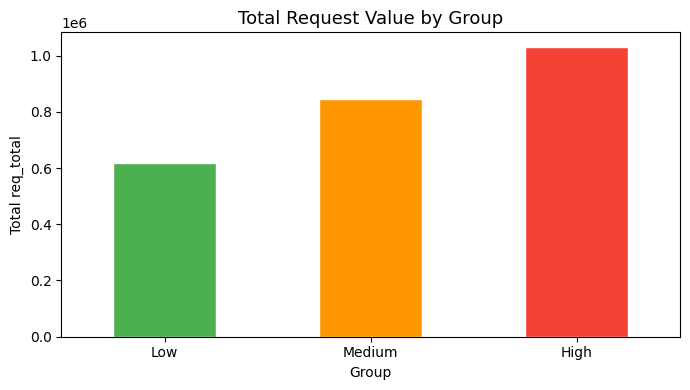

In [9]:
group_totals = requests.groupby('request_amount_group')['req_total'].sum().reindex(['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(7, 4))
group_totals.plot.bar(ax=ax, color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='white')
ax.set_title('Total Request Value by Group', fontsize=13)
ax.set_xlabel('Group')
ax.set_ylabel('Total req_total')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
# Part B — Vector Operations & Normal Distribution

Tasks covering NumPy vector creation, filtering, transformation, and generating/visualising normally distributed data.

## Setup

In [10]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.4.4


---
## Task 1 — Create Vector v (1 to 50)

Use `np.arange` to build a vector containing integers 1 through 50.

In [11]:
v = np.arange(1, 51)
print("Vector v:")
print(v)

Vector v:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]


---
## Task 2 — Total Value of All Elements in v

Sum every element using `v.sum()`.

In [12]:
total = v.sum()
print(f"Sum of all elements in v: {total}")

Sum of all elements in v: 1275


---
## Task 3 — Elements Greater Than 10 and Less Than 40

Apply a boolean mask: `(v > 10) & (v < 40)`.

In [13]:
filtered = v[(v > 10) & (v < 40)]
print("Elements where value > 10 and < 40:")
print(filtered)

Elements where value > 10 and < 40:


[11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34
 35 36 37 38 39]


---
## Task 4 — New Vector: Each Element Doubled

Create `v2` where every element equals `v[i] × 2`.

In [14]:
v2 = v * 2
print("New vector v2 (v × 2):")
print(v2)

New vector v2 (v × 2):
[  2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34  36
  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70  72
  74  76  78  80  82  84  86  88  90  92  94  96  98 100]


---
## Task 5 — Generate Normal Data and Scatterplot

Generate **60** samples each for X and Y from a normal distribution with **mean = 0** and **sd = 0.6**, then plot as a scatterplot.

Generated 60 samples for X and Y
X — mean: -0.0928, std: 0.5406
Y — mean: -0.0022, std: 0.5613


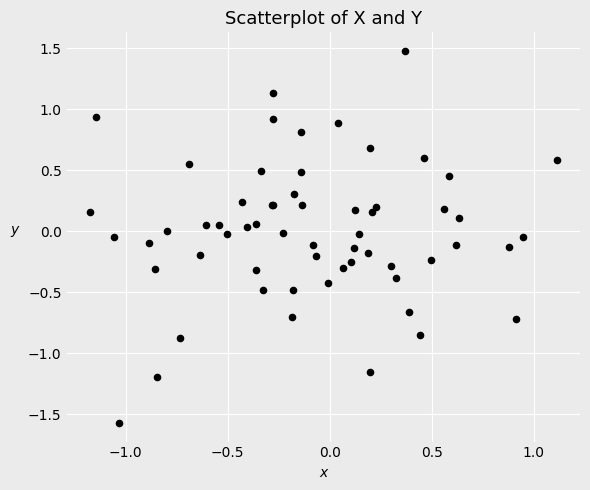

Scatterplot saved to scatterplot_xy.jpg


In [15]:
np.random.seed(42)
x = np.random.normal(loc=0, scale=0.6, size=60)
y = np.random.normal(loc=0, scale=0.6, size=60)

print(f"Generated {len(x)} samples for X and Y")
print(f"X — mean: {x.mean():.4f}, std: {x.std():.4f}")
print(f"Y — mean: {y.mean():.4f}, std: {y.std():.4f}")

fig, ax = plt.subplots(figsize=(6, 5), facecolor='#EBEBEB')
ax.set_facecolor('#EBEBEB')

ax.scatter(x, y, color='black', s=20, zorder=3)

ax.set_title('Scatterplot of X and Y', fontsize=13)
ax.set_xlabel('x', fontstyle='italic')
ax.set_ylabel('y', fontstyle='italic', rotation=0, labelpad=10)
ax.grid(color='white', linewidth=0.8)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('scatterplot_xy.jpg', format='jpeg', dpi=150)
plt.show()
print('Scatterplot saved to scatterplot_xy.jpg')